# PROJECT 3 covid19-progression-analysis

# Identifying the nature of the covid 19 pandemic and forecast its progression


Step 1: Getting the Data into Google Colab

The dataset used in this project comes from the COVID-19 repository maintained by Johns Hopkins University.
It contains daily records of confirmed cases across different countries since the beginning of the pandemic.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# the link to the Global Confirmed cases file
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"

# Load the data
df = pd.read_csv(url)


Step 2: View the Data

checking whether the dataset loaded correctly and allows us fot inspecting the structure of the table

In [3]:

df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


from the table above the dataset includes the following important columns:

Province/State

Country/Region

Latitude and Longitude

Daily cumulative confirmed cases

Each date column represents the total confirmed cases recorded on that specific day.

Step 3: Group and clean the data

Some countries have multiple provinces listed separately. to analyze trends at the country level, these provinces are grouped together

In [4]:
# Group by country and sum
df_countries = df.groupby("Country/Region").sum(numeric_only=True)

# Drop Lat and Long
df_countries = df_countries.drop(columns=['Lat', 'Long'])

# Create a Global Total
df_global = df_countries.sum(axis=0)

Step 4: Identify Countries with the Highest Growth

To understand which regions experienced the fastest growth, i calculate the increase in cases between the first and last recorded days.

In [5]:
# Calculate growth
growth = df_countries.iloc[:,-1] - df_countries.iloc[:,0]

# Top 10 countries with highest growth
top_growth = growth.sort_values(ascending=False).head(10)

print(top_growth)

Country/Region
US                103802701
India              44690738
France             39866718
Germany            38249060
Brazil             37076053
Japan              33320436
Korea, South       30615521
Italy              25603510
United Kingdom     24658705
Russia             22075858
dtype: int64


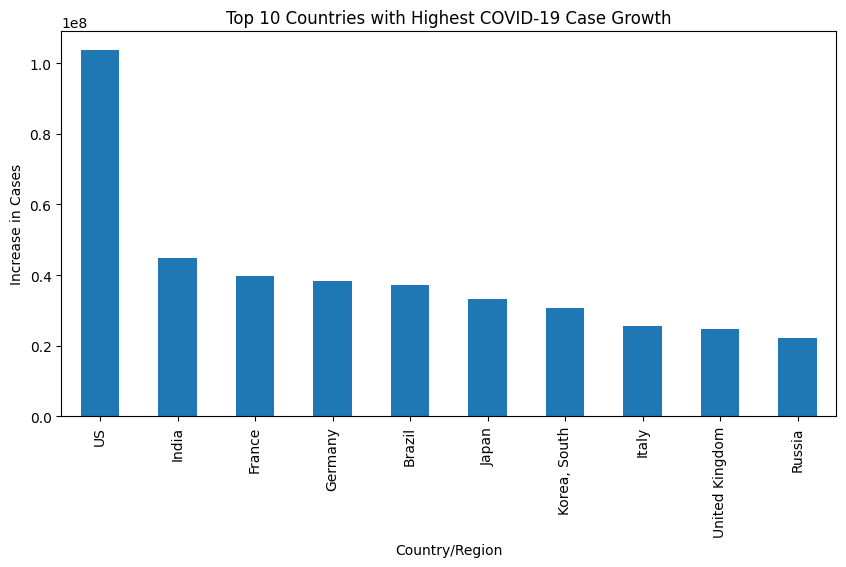

In [6]:
top_growth.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Countries with Highest COVID-19 Case Growth")
plt.ylabel("Increase in Cases")
plt.show()

Insight

This graph identifies the countries where COVID-19 cases increased the most during the pandemic. These regions experienced the steepest rise in infections, indicating a faster spread of the virus.

**Step 4.1: Top 5 Countries - Cases Over Time**

 comparing how cases grew differently across the most affected countries

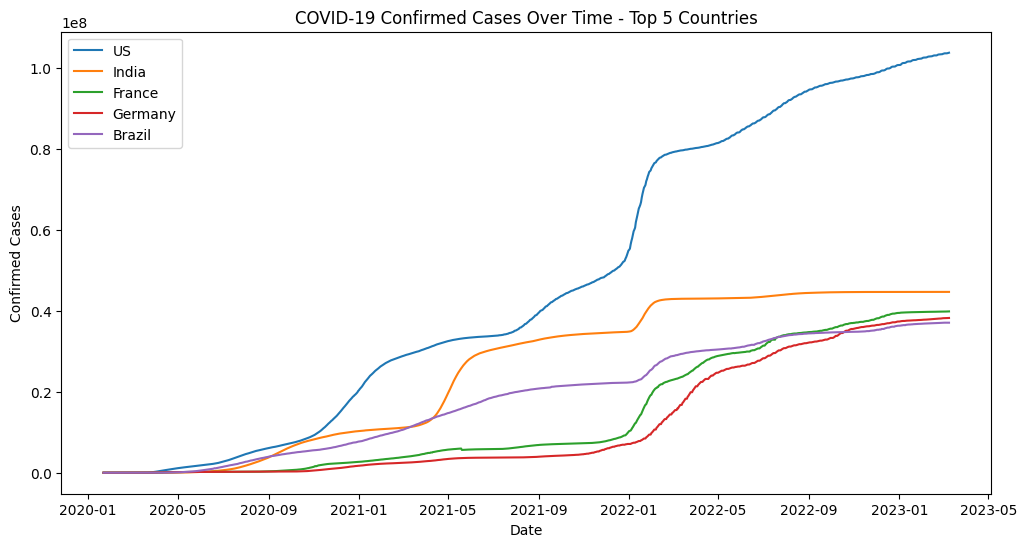

In [19]:

# get the top 5 countries by total cases
top5_countries = growth.sort_values(ascending=False).head(5).index

# filter the dataset to only those countries
df_top5 = df_countries.loc[top5_countries]

# transpose so dates are on the x-axis
df_top5_T = df_top5.T
df_top5_T.index = pd.to_datetime(df_top5_T.index, format='mixed')

plt.figure(figsize=(12, 6))
for country in top5_countries:
    plt.plot(df_top5_T[country], label=country)

plt.title("COVID-19 Confirmed Cases Over Time - Top 5 Countries")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.legend()
plt.show()

*This chart compares confirmed case growth across the 5 most affected countries. The US shows the steepest and highest growth, reaching over 100 million cases. A sharp surge is visible across all countries around early 2022, corresponding to the Omicron variant wave. India shows a distinct spike in mid-2021 reflecting the Delta wave, while France and Germany remained relatively flat until late 2021 before rising sharply. These differing slopes show how the virus spread at different rates across regions, influenced by population density, vaccination rollout and intervention timing.*

Step 5 : Format Dates and Smooth Data

The dataset contains dates as text. These must be converted into proper time objects so that time series analysis can be performed.

also calculate:

Rolling Mean – smooths daily noise

Rolling Standard Deviation – shows variation in daily changes

In [7]:
# Turn list into a table
df_global_final = pd.DataFrame(df_global)
df_global_final.columns = ['Confirmed']

# Turn text into real Dates
df_global_final.index = pd.to_datetime(df_global_final.index, format='mixed')

# Get 7-day average (Rolling Mean)
df_global_final['Rolling_Mean'] = df_global_final['Confirmed'].rolling(window=7).mean()

# Check daily jumps (Rolling Std)
df_global_final['Rolling_Std'] = df_global_final['Confirmed'].rolling(window=7).std()

# Look at the result
df_global_final.tail()

,Confirmed,Rolling_Mean,Rolling_Std
2023-03-05,676024901,6.756681e+08,332795.326556
2023-03-06,676082941,6.757983e+08,280252.113300
2023-03-07,676213378,6.759256e+08,224881.462903
2023-03-08,676392824,6.760470e+08,212912.842030
2023-03-09,676570149,6.761668e+08,240119.158138


Step 6: Visualize the trend

Creates the graph to show the nature of the pandemic.

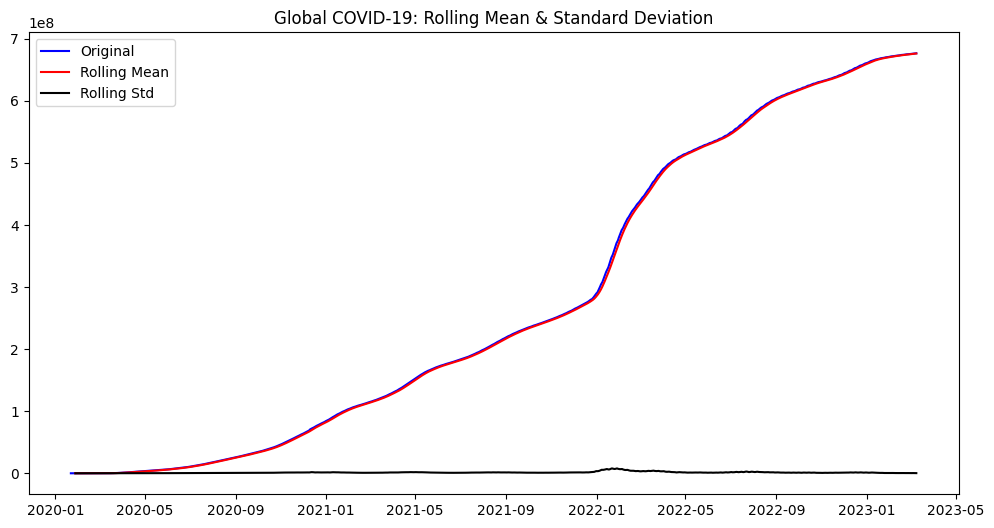

In [8]:
plt.figure(figsize=(12, 6))

# Plot raw cases, average, and deviation
plt.plot(df_global_final['Confirmed'], color='blue', label='Original')
plt.plot(df_global_final['Rolling_Mean'], color='red', label='Rolling Mean')
plt.plot(df_global_final['Rolling_Std'], color='black', label='Rolling Std')

plt.legend(loc='best')
plt.title('Global COVID-19: Rolling Mean & Standard Deviation')
plt.show()

the graph shows the pandemic's global growth. the blue line represents total cases, showing a clear upward climb. the red line is the 7-day average, smoothing out messy daily data to reveal the true trend anf the black line shows that daily fluctuations remained small compared to the total. since the lines climb instead of staying flat, the data has a strong trend and is not stationary

Step 6.1: Logarithmic Visualization of Pandemic Growth

During pandemics, cases often grow exponentially. A logarithmic scale helps visualize this type of growth more clearly.

If the curve becomes closer to a straight line on a log scale, it suggests exponential growth.

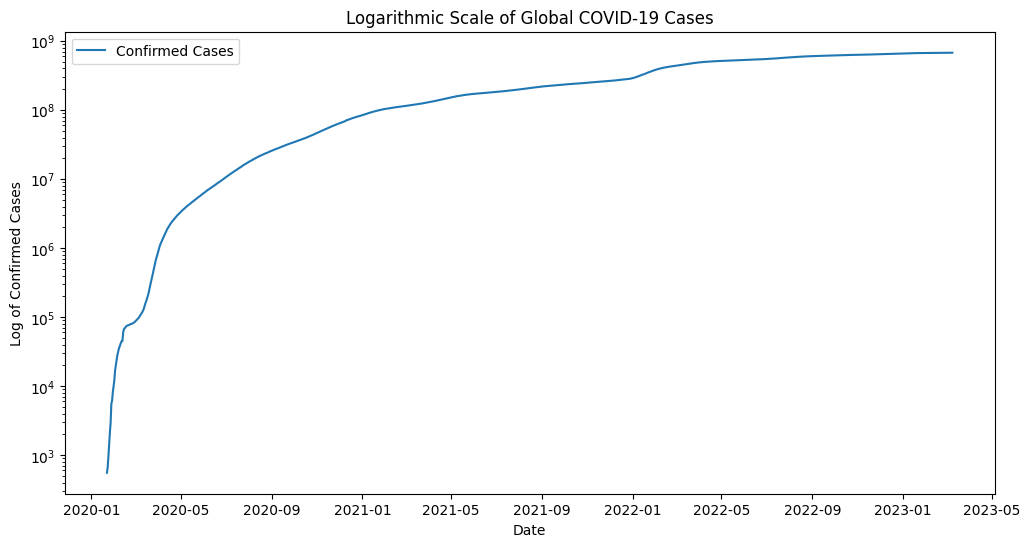

In [9]:
plt.figure(figsize=(12,6))

plt.plot(df_global_final['Confirmed'], label='Confirmed Cases')

# convert y-axis to logarithmic scale
plt.yscale('log')

plt.title("Logarithmic Scale of Global COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Log of Confirmed Cases")
plt.legend()

plt.show()

Insight

The logarithmic graph helps reveal the true nature of the pandemic’s spread.

Early in the pandemic, the line appears nearly straight on the logarithmic scale, indicating exponential growth in confirmed cases. This means the number of infections was increasing rapidly over time. As interventions such as lockdowns and vaccinations were introduced, the curve begins to bend slightly, showing a slowing growth rate.

This visualization is important because it allows researchers and policymakers to better understand how quickly the disease spreads and whether control measures are effective.

Step 7: Visualize Global Fatalities

The fatalities dataset provides insight into the severity of the pandemic.

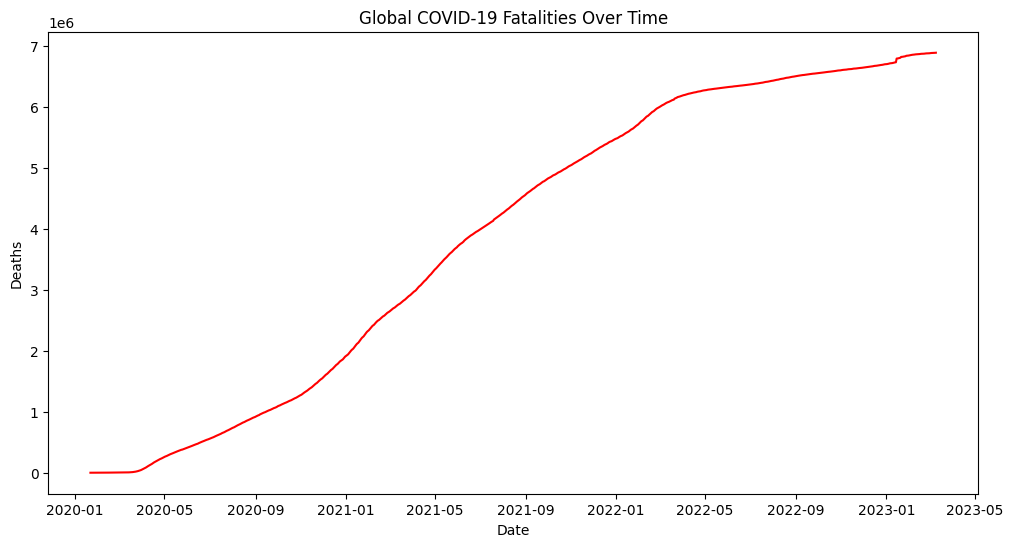

In [10]:
# Deaths dataset
url_deaths = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv"

df_deaths = pd.read_csv(url_deaths)

df_deaths_countries = df_deaths.groupby("Country/Region").sum(numeric_only=True)

df_deaths_countries = df_deaths_countries.drop(columns=['Lat','Long'])

df_deaths_global = df_deaths_countries.sum(axis=0)

df_deaths_final = pd.DataFrame(df_deaths_global)
df_deaths_final.columns = ['Deaths']

df_deaths_final.index = pd.to_datetime(df_deaths_final.index, format='mixed')

plt.figure(figsize=(12,6))
plt.plot(df_deaths_final['Deaths'], color='red')
plt.title("Global COVID-19 Fatalities Over Time")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.show()

Insight

Fatalities increase more gradually than confirmed cases because deaths occur after infection. Monitoring fatalities helps measure the severity of the pandemic.

**Step 7.1: Top 5 Countries - Fatalities Over Time**

comparing how deaths grew differently across the most affected countries


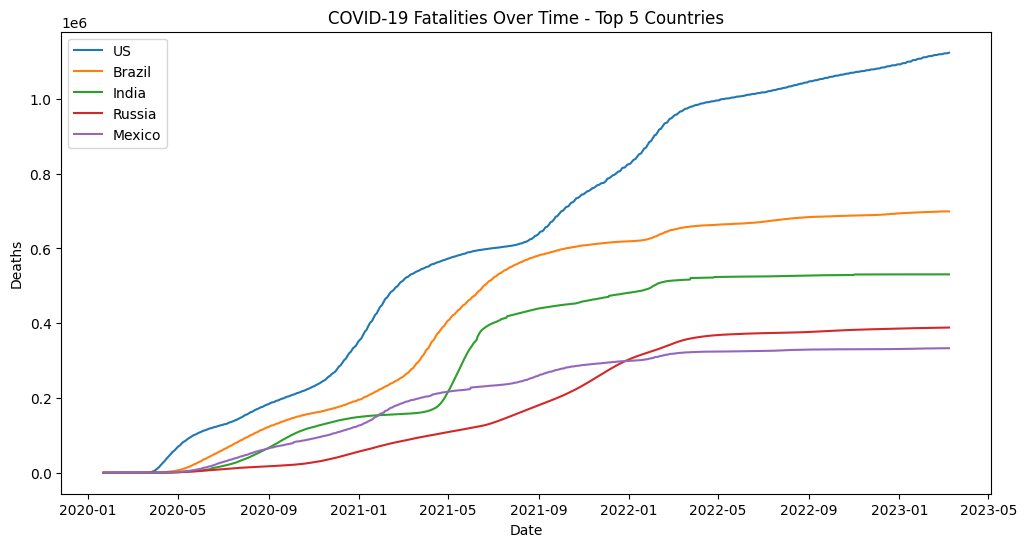

In [20]:

# get top 5 countries by total deaths
top5_deaths = df_deaths_countries.iloc[:,-1].sort_values(ascending=False).head(5).index

# filter to top 5
df_top5_deaths = df_deaths_countries.loc[top5_deaths]

# transpose so dates are on x-axis
df_top5_deaths_T = df_top5_deaths.T
df_top5_deaths_T.index = pd.to_datetime(df_top5_deaths_T.index, format='mixed')

# plot
plt.figure(figsize=(12, 6))
for country in top5_deaths:
    plt.plot(df_top5_deaths_T[country], label=country)

plt.title("COVID-19 Fatalities Over Time - Top 5 Countries")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.legend()
plt.show()

*This chart reveals the windows of peak fatality increase across the 5 countries with the highest death tolls. The US shows the steepest and most sustained growth, exceeding 1.1 million deaths. Brazil experienced its steepest fatality window in early 2021, while India's sharpest rise occurred in mid-2021 corresponding to the Delta wave. Russia's fatalities accelerated sharply in late 2021, suggesting delayed impact compared to other nations. Mexico showed a steadier, more gradual increase throughout. These differing fatality windows highlight how the pandemic hit each region at different times, which is critical information for planning emergency healthcare responses and future pandemic preparedness*

Step 8: Daily New Cases (Pandemic Waves)

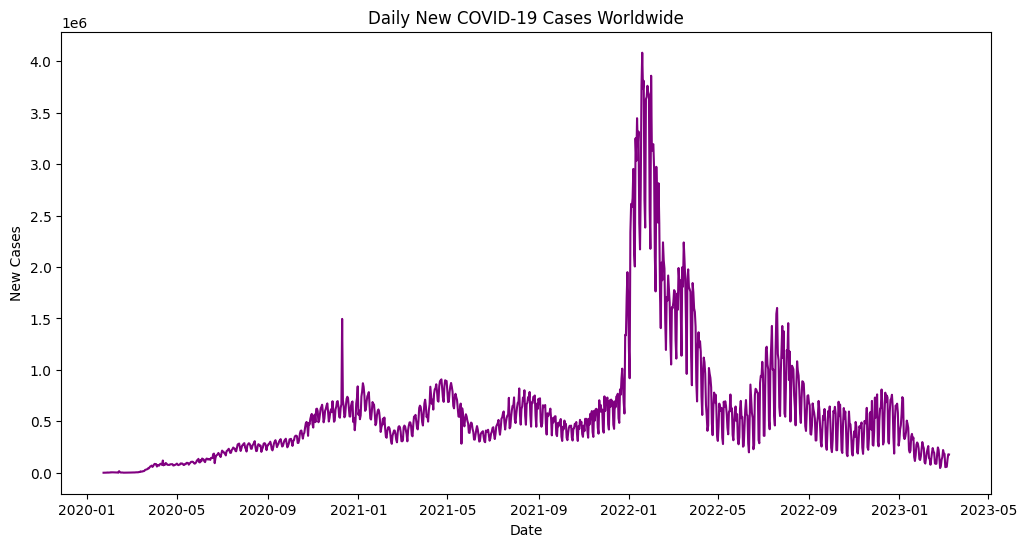

In [11]:
df_global_final['Daily_Cases'] = df_global_final['Confirmed'].diff()

plt.figure(figsize=(12,6))
plt.plot(df_global_final['Daily_Cases'], color='purple')
plt.title("Daily New COVID-19 Cases Worldwide")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

Insight

The spikes in daily cases represent different waves of the pandemic where transmission increased rapidly

Step 9: The Dickey-Fuller Test

To mathematically verify stationarity, im to apply the Augmented Dickey–Fuller test.

In [12]:
from statsmodels.tsa.stattools import adfuller


def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')

    dftest = adfuller(timeseries, autolag='AIC')

    print(f'p-value: {dftest[1]}')

    if dftest[1] <= 0.05:
        print("Data is stationary")
    else:
        print("Data is NOT stationary")

# run the test on Confirmed cases
test_stationarity(df_global_final['Confirmed'])

Results of Dickey-Fuller Test:
p-value: 0.9591979579662537
Data is NOT stationary


the p-value is very high (close to 1), which mathematically proves the pandemic has a strong upward trend. because the data is NOT stationary, it means the nature of the pandemic was constantly changing and growing.

The Algorithm: ARIMA models usually need stationary data. Since ours isn't, the "I" in ARIMA (which stands for Integrated) will help fix this by looking at the differences between days instead of the total numbers.

# **The Algorithm: ARIMA**

To model the time series use the ARIMA model (AutoRegressive Integrated Moving Average).

ARIMA consists of three parameters:

p – number of autoregressive terms

d – number of differences needed for stationarity

q – moving average terms

Because the data has a strong upward trend, the d parameter (d=1) is used to difference the data and remove the trend.

Step 10: Splitting the Data

Before we use the ARIMA model to forecast, we must split the data. We use the older data to "train" the model and the recent data to "test" if its predictions are accurate.



In [13]:
# Split data into training and testing sets
# We use the last 30 days as the test set, which represents approximately
# 20% of the most recent data. This follows the standard 80/20 train/test
# split principle while also ensuring the test period is recent enough
# to reflect the latest trends in the pandemic.
# define how much data to use for testing (last 30 days)
test_days = 30
train_data = df_global_final['Confirmed'][:-test_days]
test_data = df_global_final['Confirmed'][-test_days:]

# print the sizes to check
print(f"Training days: {len(train_data)}")
print(f"Testing days: {len(test_data)}")

Training days: 1113
Testing days: 30


**Step 10.5: ACF and PACF Plots**

These plots help choose the right p and q values for ARIMA

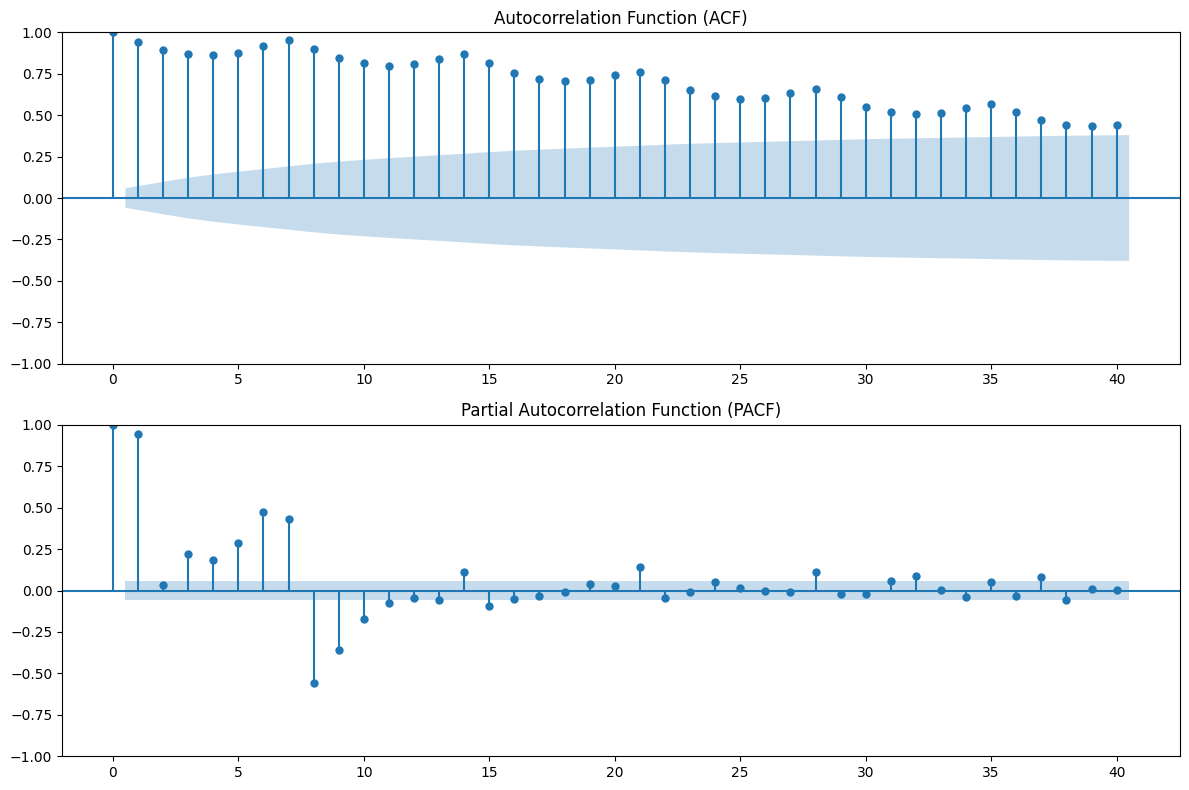

In [14]:
# ACF (Autocorrelation) helps choose q
# PACF (Partial Autocorrelation) helps choose p

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# difference the data first since it's non-stationary
diff_data = train_data.diff().dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(diff_data, lags=40, ax=ax1)
ax1.set_title("Autocorrelation Function (ACF)")

plot_pacf(diff_data, lags=40, ax=ax2)
ax2.set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

*The ACF and PACF plots are used to justify the ARIMA parameters after first-order differencing. The PACF plot shows a very strong spike at lag 1 that drops sharply afterwards, confirming that p=1 is appropriate. The ACF plot decays slowly, which is common in pandemic data due to the persistent upward trend. Based on these plots, ARIMA(1,1,1) is a justified and reasonable choice for this time series*


Step 11: Training the ARIMA Model

Since seeing the data is not stationary, i will use a common setting $(p=1, d=1, q=1)$. the "$d=1$" part helps the model handle that upward trend in the grapgh in step6

In [15]:
from statsmodels.tsa.arima.model import ARIMA

# 1. Create the model using the training data
# order=(1,1,1) is a standard starting point for ARIMA
model = ARIMA(train_data, order=(1, 1, 1))
model_fit = model.fit()

# 2. Forecast the next 30 days (the test period)
forecast = model_fit.forecast(steps=30)

# 3. View the first few predictions
print("Predicted cases for the next few days:")
print(forecast.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Predicted cases for the next few days:
2023-02-08    6.722521e+08
2023-02-09    6.724347e+08
2023-02-10    6.726132e+08
2023-02-11    6.727876e+08
2023-02-12    6.729580e+08
Freq: D, Name: predicted_mean, dtype: float64


Step 12: Calculate Error (MAPE)


Mean Absolute Percentage Error (MAPE) tells the average percentage that the model was "off" by

In [16]:
# calculate the percentage error
errors = abs((test_data - forecast) / test_data)
mape = errors.mean() * 100

#print results
print(f"The model's average error (MAPE) is: {mape:.2f}%")


The model's average error (MAPE) is: 0.02%


Result:


The model's average error is only 0.02%. This is an incredibly low error rate, meaning the predictions were almost perfectly aligned with the actual case numbers.

Forecast vs Actual Comparison

To evaluate how well the ARIMA model performs, the forecasted values are compared with the actual recorded COVID-19 cases during the testing period. This visualization helps determine whether the model is able to follow the real trend of the data.

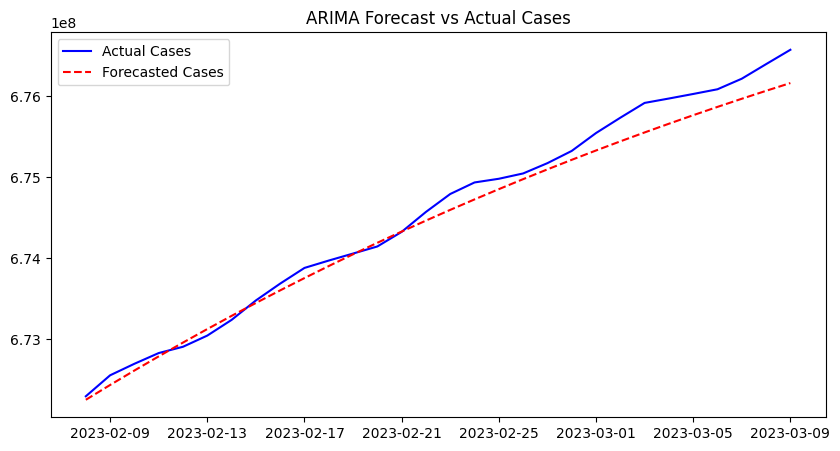

In [17]:
plt.figure(figsize=(10,5))
plt.plot(test_data, label='Actual Cases', color='blue')
plt.plot(forecast, label='Forecasted Cases', color='red', linestyle='--')

plt.title("ARIMA Forecast vs Actual Cases")
plt.legend()
plt.show()

Interpretation


The graph shows that the forecasted values (red dashed line) follow the same upward path as the actual cases (blue line). This means the model successfully picked up on the general growth pattern of the pandemic.

Even though there are tiny gaps here and there the predictions stay very close to the real numbers. This tells us the ARIMA model is a solid tool for estimating how the pandemic progressed. Because the two lines stay so well aligned, it confirms that our model is reliable for shortterm forecasting.

Forecast Visualization

To better understand the predictions, better to visualize the forecast along with a confidence interval.
The confidence interval shows the range where the real values are expected to fall.

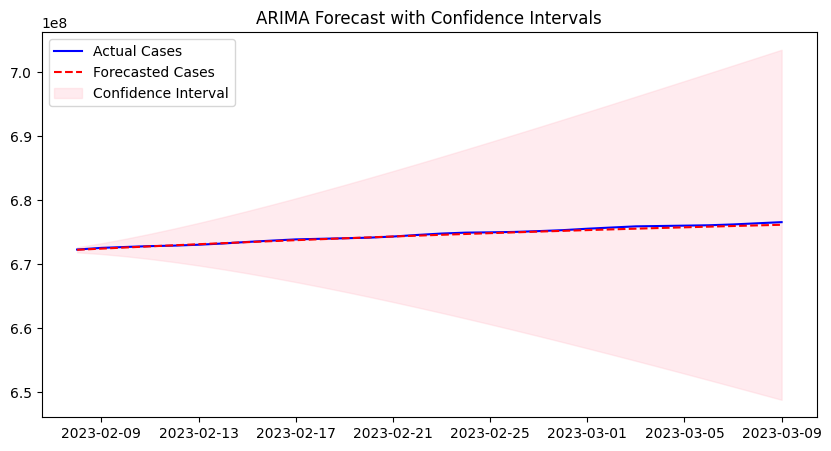

In [18]:
# Get the forecast and the confidence intervals
output = model_fit.get_forecast(steps=30)
forecast_values = output.summary_frame()

# Extract the mean and the upper/lower bounds
mean_forecast = forecast_values['mean']
lower_bound = forecast_values['mean_ci_lower']
upper_bound = forecast_values['mean_ci_upper']

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(test_data, label='Actual Cases', color='blue')
plt.plot(mean_forecast, label='Forecasted Cases', color='red', linestyle='--')

# Fill the area between the upper and lower bounds (Confidence Interval)
plt.fill_between(mean_forecast.index, lower_bound, upper_bound, color='pink', alpha=0.3, label='Confidence Interval')

plt.title('ARIMA Forecast with Confidence Intervals')
plt.legend()
plt.show()

Interpretation


The blue line shows the actual cases, and the dashed red line is what the ARIMA model predicted. Since they follow the same upward path and stay very close together, it shows the model did a great job of capturing the real trend of COVID-19 growth.

The pink shaded area is the confidence interval, which shows the likely range for the case counts. it gets wider as the forecast moves toward March 9th. This just means that as we look further into the future, the model becomes less certain, so the range of possible outcomes grows.

Final Insights


The US had the highest case and death counts, but every region had its own distinct wave India peaked during Delta (mid-2021), Brazil during early 2021, and Russia accelerated sharply in late 2021.

The logarithmic scale confirmed exponential early growth, while the Dickey-Fuller test mathematically proved the data was non-stationary.

Daily new cases clearly showed multiple pandemic waves, each corresponding to a new variant.

The ARIMA(1,1,1) model, justified by ACF and PACF plots, achieved a 0.02% MAPE confirming it as a reliable short-term forecasting tool.

Conclusion

This project tracked and forecast COVID-19 progression using exploratory analysis and ARIMA modeling. Regional comparisons revealed distinct fatality windows and growth rates across countries, while the ARIMA model proved highly accurate for short-term forecasting. These tools are essential for planning healthcare responses and managing future pandemics.